03. SVM NATICUSdroid

In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/DavidNaranjo1237/NATICUSdroid.git'
REPO_DIR = Path('/content/NATICUSdroid')

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score  # noqa: F401
from sklearn.model_selection import GridSearchCV, StratifiedKFold

_bootstrap_dependencies = (
    np,
    pd,
    RandomForestClassifier,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    GridSearchCV,
    StratifiedKFold,
)
print(f'Bootstrap imports loaded: {len(_bootstrap_dependencies)}')

def is_colab() -> bool:
    return 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in sys.modules

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'prepare_data.py').exists():
            return candidate
    return REPO_DIR if is_colab() else Path.cwd()

repo_root = find_repo_root()
if is_colab() and not (repo_root / 'src' / 'prepare_data.py').exists():
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(repo_root)], check=True)
    else:
        print(f'Repository directory already exists at {repo_root}.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'Repository root: {repo_root}')
print('Imports listos para el entrenamiento del SVM.')

Bootstrap imports loaded: 12
Repository root: /content/NATICUSdroid
Imports listos para el entrenamiento del SVM.


Preprocesado

In [2]:
from src.prepare_data import prepare_dataset

results = prepare_dataset()
summary = results['summary']
artifacts = results['artifacts']
X_train = results['X_train']
X_test = results['X_test']
y_train = results['y_train']
y_test = results['y_test']

print('Resumen del dataset')
print(summary)
print('')
print('Artefactos generados')
for name, value in artifacts.items():
    print(f'{name}: {value}')

print('')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

Resumen del dataset
{'rows': 29332, 'columns': 87, 'feature_columns': 86, 'missing_values': 0, 'class_distribution': {'0': 14632, '1': 14700}, 'class_distribution_percent': {'0': 49.8841, '1': 50.1159}}

Artefactos generados
train_features: /content/NATICUSdroid/data/processed/X_train.csv
test_features: /content/NATICUSdroid/data/processed/X_test.csv
train_target: /content/NATICUSdroid/data/processed/y_train.csv
test_target: /content/NATICUSdroid/data/processed/y_test.csv
train_full: /content/NATICUSdroid/data/processed/train.csv
test_full: /content/NATICUSdroid/data/processed/test.csv
metadata: /content/NATICUSdroid/data/processed/split_metadata.json

X_train shape: (20532, 86)
X_test shape: (8800, 86)
y_train shape: (20532,)
y_test shape: (8800,)


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid", palette="deep")
SEED = 42
np.random.seed(SEED)

# 1. FUNCIÓN PARA INTERVALOS DE CONFIANZA (BOOTSTRAP)
def calcular_intervalo_confianza(y_real, y_pred, metrica_fn, iteraciones=1000, alfa=0.05):
    """Calcula el IC del 95% usando remuestreo Bootstrap."""
    rng = np.random.default_rng(SEED)
    n = len(y_real)
    estadisticos = np.empty(iteraciones)

    for i in range(iteraciones):
        indices = rng.integers(0, n, n)
        estadisticos[i] = metrica_fn(y_real[indices], y_pred[indices])

    limite_inf = np.percentile(estadisticos, 100 * (alfa / 2))
    limite_sup = np.percentile(estadisticos, 100 * (1 - alfa / 2))
    return limite_inf, limite_sup

In [4]:
# 2. ASEGURAR FORMATO NUMPY PARA EVITAR ERRORES DE ÍNDICES
X_tr = np.asarray(X_train)
y_tr = np.asarray(y_train)
X_te = np.asarray(X_test)
y_te = np.asarray(y_test)

In [5]:
# 3. VALIDACIÓN CRUZADA - BÚSQUEDA DE HIPERPARÁMETROS
valores_C = [0.01, 0.1, 1, 10, 100]
validador_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv = []

print("Iniciando Validación Cruzada para LinearSVC...\n")
tiempo_inicio = time.time()

for c in valores_C:
    metricas_fold = {'acc': [], 'f1': [], 'auc': [], 'vectores_soporte': []}

    for train_idx, val_idx in validador_kfold.split(X_tr, y_tr):
        # Separación por pliegues
        X_kf_train, X_kf_val = X_tr[train_idx], X_tr[val_idx]
        y_kf_train, y_kf_val = y_tr[train_idx], y_tr[val_idx]

        # Escalado de datos independiente por pliegue (Evita Data Leakage)
        escalador = StandardScaler()
        X_kf_train_s = escalador.fit_transform(X_kf_train)
        X_kf_val_s = escalador.transform(X_kf_val)

        # Entrenamiento
        modelo_svm = LinearSVC(C=c, loss='squared_hinge', max_iter=4000,
                               random_state=SEED, dual="auto")
        modelo_svm.fit(X_kf_train_s, y_kf_train)

        # Predicciones
        preds_val = modelo_svm.predict(X_kf_val_s)
        decision_val = modelo_svm.decision_function(X_kf_val_s)

        # Registro de métricas
        metricas_fold['acc'].append(accuracy_score(y_kf_val, preds_val))
        metricas_fold['f1'].append(f1_score(y_kf_val, preds_val, zero_division=0))
        metricas_fold['auc'].append(roc_auc_score(y_kf_val, decision_val))

        # Aproximación de Vectores de Soporte (Muestras dentro del margen)
        decision_train = modelo_svm.decision_function(X_kf_train_s)
        margen = y_kf_train * decision_train
        pct_sv = np.mean(margen <= 1.00000001) * 100
        metricas_fold['vectores_soporte'].append(pct_sv)

    # Promediar los pliegues para el parámetro C actual
    resultados_cv.append({
        "C": c,
        "F1_Promedio": np.mean(metricas_fold['f1']),
        "F1_Std": np.std(metricas_fold['f1']),
        "Acc_Promedio": np.mean(metricas_fold['acc']),
        "AUC_Promedio": np.mean(metricas_fold['auc']),
        "Pct_SV_Aprox": np.mean(metricas_fold['vectores_soporte'])
    })

print(f"Búsqueda finalizada en {time.time() - tiempo_inicio:.2f} segundos.\n")
df_resultados = pd.DataFrame(resultados_cv)
display(df_resultados)

Iniciando Validación Cruzada para LinearSVC...

Búsqueda finalizada en 16.48 segundos.



,C,F1_Promedio,F1_Std,Acc_Promedio,AUC_Promedio,Pct_SV_Aprox
0,0.01,0.960670,0.002245,0.960354,0.988727,65.386963
1,0.10,0.960520,0.002220,0.960208,0.988675,64.699008
2,1.00,0.960614,0.002305,0.960306,0.988669,64.606470
3,10.00,0.960567,0.002286,0.960257,0.988661,64.606470
4,100.00,0.960567,0.002286,0.960257,0.988659,64.607688


In [6]:
# 4. SELECCIÓN Y ENTRENAMIENTO DEL MODELO FINAL
# Encontrar el mejor C basado en el F1-Score más alto
mejor_c = df_resultados.loc[df_resultados["F1_Promedio"].idxmax(), "C"]
print(f"\nEntrenando modelo final con la mejor regularización: C = {mejor_c}")

# Escalar el conjunto de entrenamiento completo
escalador_final = StandardScaler()
X_tr_final = escalador_final.fit_transform(X_tr)
X_te_final = escalador_final.transform(X_te)

# Entrenar el modelo definitivo
svm_definitivo = LinearSVC(C=mejor_c, loss='squared_hinge', max_iter=5000,
                           random_state=SEED, dual="auto")
svm_definitivo.fit(X_tr_final, y_tr)

# Predicciones finales en el conjunto de PRUEBA (Test)
preds_test = svm_definitivo.predict(X_te_final)
decisiones_test = svm_definitivo.decision_function(X_te_final)

# Calcular IC95% para test
ic_acc = calcular_intervalo_confianza(y_te, preds_test, accuracy_score)
ic_f1 = calcular_intervalo_confianza(y_te, preds_test, lambda a, b: f1_score(a, b, zero_division=0))

print("\n" + "="*35)
print(" RESULTADOS EN CONJUNTO DE PRUEBA")
print("="*35)
print(f"Exactitud (Accuracy) : {accuracy_score(y_te, preds_test):.4f}  | IC 95%: [{ic_acc[0]:.4f}, {ic_acc[1]:.4f}]")
print(f"Precisión (Precision): {precision_score(y_te, preds_test, zero_division=0):.4f}")
print(f"Sensibilidad (Recall): {recall_score(y_te, preds_test, zero_division=0):.4f}")
print(f"F1-Score             : {f1_score(y_te, preds_test, zero_division=0):.4f}  | IC 95%: [{ic_f1[0]:.4f}, {ic_f1[1]:.4f}]")
print(f"Área ROC (AUC)       : {roc_auc_score(y_te, decisiones_test):.4f}")
print("="*35)


Entrenando modelo final con la mejor regularización: C = 0.01

 RESULTADOS EN CONJUNTO DE PRUEBA
Exactitud (Accuracy) : 0.9591  | IC 95%: [0.9549, 0.9631]
Precisión (Precision): 0.9540
Sensibilidad (Recall): 0.9649
F1-Score             : 0.9594  | IC 95%: [0.9551, 0.9636]
Área ROC (AUC)       : 0.9885


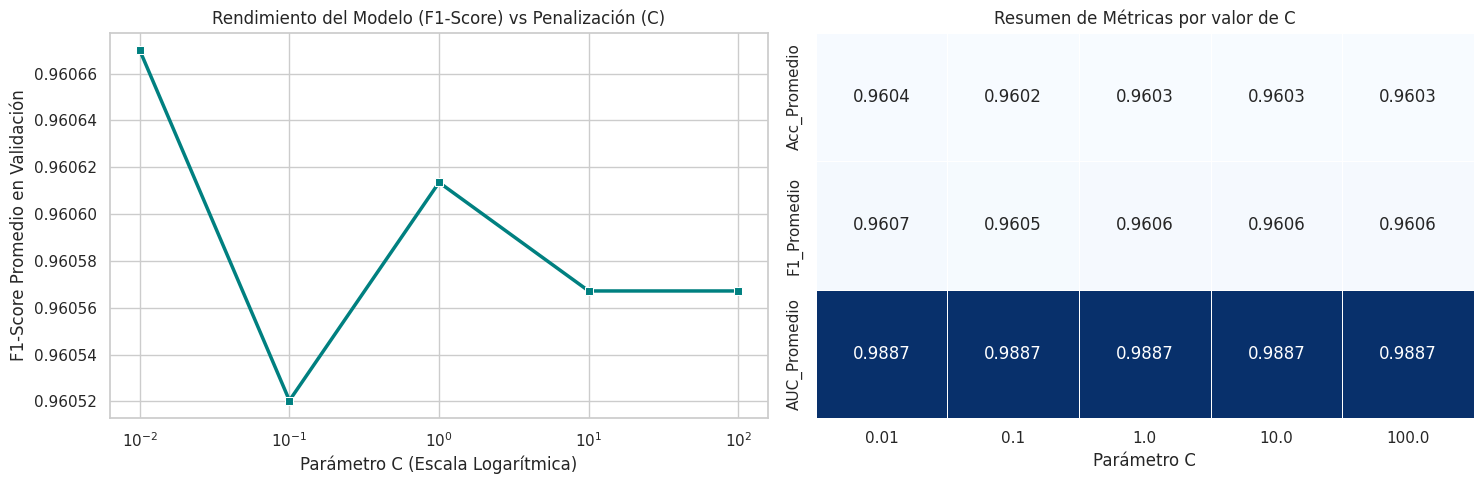

In [7]:
# 5. VISUALIZACIÓN MULTIPANEL DE LOS RESULTADOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de líneas para F1 vs C
sns.lineplot(data=df_resultados, x="C", y="F1_Promedio", marker='s', ax=ax1, color='teal', linewidth=2.5)
ax1.set_xscale('log')
ax1.set_title('Rendimiento del Modelo (F1-Score) vs Penalización (C)')
ax1.set_xlabel('Parámetro C (Escala Logarítmica)')
ax1.set_ylabel('F1-Score Promedio en Validación')

# Mapa de calor de las métricas principales
mapa_datos = df_resultados.set_index("C")[["Acc_Promedio", "F1_Promedio", "AUC_Promedio"]].T
sns.heatmap(mapa_datos, annot=True, cmap='Blues', fmt=".4f", cbar=False, ax=ax2, linewidths=.5)
ax2.set_title('Resumen de Métricas por valor de C')
ax2.set_xlabel('Parámetro C')

plt.tight_layout()
plt.show()